# **Ford GoBike (Bay Wheels) 2018 Trip Data - Exploratory Data Analysis**

##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual

# **Project Summary -**

This project explores the **Ford GoBike** (now Bay Wheels) bike-share trip data for the
San Francisco Bay Area covering all 12 months of **2018** (January - December). Ford GoBike is a
regional public bicycle sharing system, and each record in the dataset represents a single bike trip,
capturing when and where the trip started and ended, how long it lasted, which bike was used, and
information about the rider (subscriber vs. casual customer, age, and gender).

Twelve monthly CSV files (`201801` through `201812`) were combined into a single dataset of
**1,863,721 trips**. After merging, the data was cleaned: timestamps were parsed into proper
datetime objects, trip duration was converted from seconds to minutes, rider age was derived from
birth year, and new time-based features (month, day of week, hour, season, weekend flag) were
engineered to support the analysis. Rows with missing station, birth-year, or gender information
(about 6% of trips) and a small number of unrealistic outliers (ages above 90 and trips longer than
12 hours) were removed for the "clean" analysis dataset, leaving **1,739,029 trips**.

The core question driving this analysis is: **how long does the average trip take, is that duration
affected by weather/season, and does the answer depend on whether the rider is a Subscriber
(member) or a Customer (casual/one-off rider)?** Beyond that central question, the notebook also
explores usage patterns by hour of day, day of week, and month, rider demographics (age and
gender), and the most popular stations.

The key finding is that **season/weather has only a small effect on trip duration**, while
**user type has a very large effect**: Customers take substantially longer trips (median ~14.6
minutes, mean ~23.2 minutes) than Subscribers (median ~8.6 minutes, mean ~10.8 minutes).
Subscribers dominate the ridership (~89% of trips) and show a strong commute pattern with peaks
at 8 AM and 5 PM on weekdays, while Customers ride more on weekends and show flatter usage
throughout the day. These patterns suggest Subscribers primarily use the service for commuting,
while Customers use it more for leisure and exploration - a distinction with clear implications for
how the business could grow its subscriber base and tailor pricing/marketing by rider segment.

# **GitHub Link -**

_Provide your GitHub repository link here after uploading this notebook._

# **Problem Statement**

Ford GoBike (Bay Wheels) wants to better understand how people use its bike-share system so
it can improve operations, pricing, and marketing. Trip duration is closely tied to bike availability,
rebalancing costs, and ultimately revenue (since pricing is duration- and membership-based), so the
company needs to understand **what drives trip duration** and **how usage differs between its two
customer segments** (paying members vs. casual riders).

**Features available in the data:**
Trip Duration (seconds), Start Time and Date, End Time and Date, Start Station ID, Start Station
Name, Start Station Latitude, Start Station Longitude, End Station ID, End Station Name, End
Station Latitude, End Station Longitude, Bike ID, User Type (Subscriber = Member or Customer =
Casual), Member Year of Birth, Member Gender, Bike Share for All Trip flag.

**Questions to be answered:**
1. How long does the average trip take?
2. Is trip duration affected by weather/season (month)?
3. Does the above depend on whether a user is a Subscriber or a Customer?


#### **Define Your Business Objective?**

Identify the key factors that drive trip duration and ridership patterns (season, time of day,
day of week, and especially user type) so that Ford GoBike can (a) understand its revenue drivers,
since trip duration and rider volume feed directly into revenue, and (b) design targeted strategies
- such as converting frequent Customers into Subscribers and optimizing bike availability around
commute peaks - to grow ridership and revenue.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

### Dataset Loading

In [3]:
# All 12 monthly CSV files (201801-fordgobike-tripdata.csv ... 201812-fordgobike-tripdata.csv)
# are expected to live in the same folder as this notebook. Change DATA_PATH if needed.
DATA_PATH = './'

file_list = sorted(glob.glob(DATA_PATH + '*-fordgobike-tripdata.csv'))
print(f'Found {len(file_list)} files:')
for f in file_list:
    print(' -', f)

Found 12 files:
 - ./201801-fordgobike-tripdata.csv
 - ./201802-fordgobike-tripdata.csv
 - ./201803-fordgobike-tripdata.csv
 - ./201804-fordgobike-tripdata.csv
 - ./201805-fordgobike-tripdata.csv
 - ./201806-fordgobike-tripdata.csv
 - ./201807-fordgobike-tripdata.csv
 - ./201808-fordgobike-tripdata.csv
 - ./201809-fordgobike-tripdata.csv
 - ./201810-fordgobike-tripdata.csv
 - ./201811-fordgobike-tripdata.csv
 - ./201812-fordgobike-tripdata.csv


In [4]:
# Merge all 12 monthly files into a single DataFrame
df_list = []
for f in file_list:
    monthly_df = pd.read_csv(f)
    monthly_df['source_file'] = f.split('/')[-1]   # keep track of the origin file
    df_list.append(monthly_df)

df = pd.concat(df_list, ignore_index=True)
print('Merged dataset shape:', df.shape)

Merged dataset shape: (1863721, 17)


### Dataset First View

In [5]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,source_file
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No,201801-fordgobike-tripdata.csv
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No,201801-fordgobike-tripdata.csv
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No,201801-fordgobike-tripdata.csv
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No,201801-fordgobike-tripdata.csv
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No,201801-fordgobike-tripdata.csv


In [6]:
df.tail()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,source_file
1863716,473,2018-12-01 00:11:54.8110,2018-12-01 00:19:48.5470,345.0,Hubbell St at 16th St,37.766474,-122.398295,81.0,Berry St at 4th St,37.775880,-122.393170,3035,Subscriber,1982.0,Female,No,201812-fordgobike-tripdata.csv
1863717,841,2018-12-01 00:02:48.7260,2018-12-01 00:16:49.7660,10.0,Washington St at Kearny St,37.795393,-122.404770,58.0,Market St at 10th St,37.776619,-122.417385,2034,Subscriber,1999.0,Female,No,201812-fordgobike-tripdata.csv
1863718,260,2018-12-01 00:05:27.6150,2018-12-01 00:09:47.9560,245.0,Downtown Berkeley BART,37.870139,-122.268422,255.0,Virginia St at Shattuck Ave,37.876573,-122.269528,2243,Subscriber,1991.0,Male,No,201812-fordgobike-tripdata.csv
1863719,292,2018-12-01 00:03:06.5490,2018-12-01 00:07:59.0800,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,126.0,Esprit Park,37.761634,-122.390648,545,Subscriber,1963.0,Male,No,201812-fordgobike-tripdata.csv
1863720,150,2018-12-01 00:03:05.7420,2018-12-01 00:05:36.0260,107.0,17th St at Dolores St,37.763015,-122.426497,119.0,18th St at Noe St,37.761047,-122.432642,4319,Subscriber,NaN,NaN,No,201812-fordgobike-tripdata.csv


### Dataset Rows & Columns count

In [7]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 1863721
Columns: 17


### Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 17 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
 16  source_file              object 
dtypes: float64(7), int64(2), object(8)
memory usage: 241.7+ MB


#### Duplicate Values

In [9]:
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

Number of duplicate rows: 0


#### Missing Values/Null Values

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
member_birth_year,110718,5.94
member_gender,110367,5.92
start_station_name,11771,0.63
start_station_id,11771,0.63
end_station_name,11771,0.63
end_station_id,11771,0.63


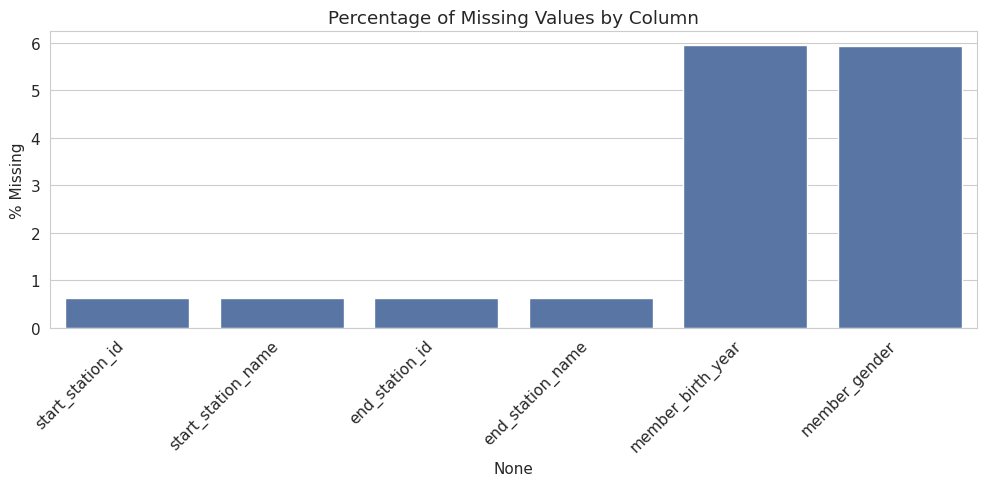

In [13]:
# Visualizing the missing values
plt.figure(figsize=(10, 5))
missing_plot = missing_df[missing_df['Missing Count'] > 0]
sns.barplot(x=missing_plot.index, y=missing_plot['Missing %'], color='#4C72B0')
plt.xticks(rotation=45, ha='right')
plt.ylabel('% Missing')
plt.title('Percentage of Missing Values by Column')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The merged dataset contains **1,863,721 trips** across 12 months of 2018 with **17 columns**
(16 original + `source_file`). There are **no duplicate rows**. Five columns have missing values:
`start_station_id`/`start_station_name` and `end_station_id`/`end_station_name` (~11.8K rows,
~0.6%), and `member_birth_year`/`member_gender` (~110K rows, ~5.9%) - these are almost certainly
trips where the rider chose not to provide demographic info or where a station lookup failed.
`duration_sec`, `start_time`, `end_time`, `bike_id`, and `user_type` are always populated. The data
types are mostly appropriate, but `start_time`/`end_time` need to be converted from text to proper
datetime objects, and station IDs (currently floats because of the NaNs) should become integers
once missing rows are handled.

## ***2. Understanding Your Variables***

In [12]:
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'source_file'],
      dtype='object')

### Variables Description

- **duration_sec**: Trip duration in seconds
- **start_time / end_time**: Trip start and end date & time
- **start_station_id / start_station_name / start_station_latitude / start_station_longitude**: Where the trip began
- **end_station_id / end_station_name / end_station_latitude / end_station_longitude**: Where the trip ended
- **bike_id**: Unique ID of the bike used
- **user_type**: `Subscriber` (paying member) or `Customer` (casual/one-off rider)
- **member_birth_year**: Rider's birth year (used to derive age)
- **member_gender**: Rider's self-reported gender (`Male`, `Female`, `Other`)
- **bike_share_for_all_trip**: Whether the trip was part of the discounted "Bike Share for All" program (`Yes`/`No`)

### Check Unique Values for each variable.

In [14]:
for col in df.columns:
    n_unique = df[col].nunique()
    print(f'{col:30s}: {n_unique} unique values')

duration_sec                  : 16709 unique values
start_time                    : 1863584 unique values
end_time                      : 1863610 unique values
start_station_id              : 331 unique values
start_station_name            : 348 unique values
start_station_latitude        : 369 unique values
start_station_longitude       : 370 unique values
end_station_id                : 331 unique values
end_station_name              : 348 unique values
end_station_latitude          : 370 unique values
end_station_longitude         : 371 unique values
bike_id                       : 5054 unique values
user_type                     : 2 unique values
member_birth_year             : 86 unique values
member_gender                 : 3 unique values
bike_share_for_all_trip       : 2 unique values
source_file                   : 12 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# 1. Parse datetime columns
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# 2. Convert duration from seconds to minutes (easier to interpret)
df['duration_min'] = df['duration_sec'] / 60

# 3. Derive rider age from birth year (dataset year = 2018)
df['member_age'] = 2018 - df['member_birth_year']

# 4. Engineer time-based features for seasonality / usage-pattern analysis
df['month'] = df['start_time'].dt.month
df['month_name'] = df['start_time'].dt.month_name()
df['day_of_week'] = df['start_time'].dt.day_name()
df['hour'] = df['start_time'].dt.hour

def month_to_season(m):
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(month_to_season)
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

df[['duration_min', 'member_age', 'month_name', 'day_of_week', 'hour', 'season', 'is_weekend']].head()

,duration_min,member_age,month_name,day_of_week,hour,season,is_weekend
0,1254.733333,32.0,January,Wednesday,22,Winter,False
1,1423.700000,NaN,January,Wednesday,16,Winter,False
2,1192.933333,22.0,January,Wednesday,14,Winter,False
3,1017.933333,NaN,January,Wednesday,14,Winter,False
4,666.100000,27.0,January,Wednesday,19,Winter,False


In [16]:
# Sanity-check the derived columns for unrealistic values
print('Duration (min) stats:')
print(df['duration_min'].describe())
print()
print('Age stats:')
print(df['member_age'].describe())
print()
print(f"Trips with age > 90: {(df['member_age'] > 90).sum()}")
print(f"Trips longer than 12 hours (720 min): {(df['duration_min'] > 720).sum()}")

Duration (min) stats:
count    1.863721e+06
mean     1.428838e+01
std      3.950631e+01
min      1.016667e+00
25%      5.833333e+00
50%      9.266667e+00
75%      1.453333e+01
max      1.439433e+03
Name: duration_min, dtype: float64

Age stats:
count    1.753003e+06
mean     3.491204e+01
std      1.044289e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      1.370000e+02
Name: member_age, dtype: float64

Trips with age > 90: 1393
Trips longer than 12 hours (720 min): 1736


In [17]:
# Build a clean dataset for analysis:
#   - drop rows missing station info, birth year, or gender (needed for the demographic/segment analysis)
#   - drop unrealistic ages (> 90) and unrealistic durations (> 12 hours), which are almost
#     certainly data-entry errors, lost/returned bikes, or maintenance checkouts rather than real rides
clean = df.dropna(subset=['start_station_id', 'end_station_id',
                           'member_birth_year', 'member_gender']).copy()
clean = clean[clean['member_age'] <= 90]
clean = clean[clean['duration_min'] <= 720]

clean['start_station_id'] = clean['start_station_id'].astype(int)
clean['end_station_id'] = clean['end_station_id'].astype(int)

print(f'Original rows: {len(df):,}')
print(f'Clean rows:    {len(clean):,}  ({len(clean)/len(df)*100:.1f}% retained)')

Original rows: 1,863,721
Clean rows:    1,739,029  (93.3% retained)


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Concatenated 12 monthly CSVs into one DataFrame and tagged each row with its source file.
2. Converted `start_time`/`end_time` to proper `datetime` objects.
3. Converted `duration_sec` to `duration_min` for readability.
4. Derived `member_age` from `member_birth_year`.
5. Engineered `month`, `month_name`, `day_of_week`, `hour`, `season`, and `is_weekend` features
   from `start_time` to support the season/weather and time-of-day questions.
6. Created a "clean" copy of the data with rows missing station/demographic info dropped and
   unrealistic ages (>90) or durations (>12 hours) removed, retaining **93.3%** of the merged data.
   The full dataset is kept for any analysis that doesn't require demographics; the clean dataset is
   used whenever age or gender is part of the analysis.

**Early insights:** trip duration is heavily **right-skewed** - most trips are short (median about
9 minutes) but a long tail of much longer trips pulls the mean up to about 14 minutes; a log scale
is needed to visualize the distribution meaningfully.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### *Univariate Analysis*

#### Chart - 1 - Trip Duration Distribution

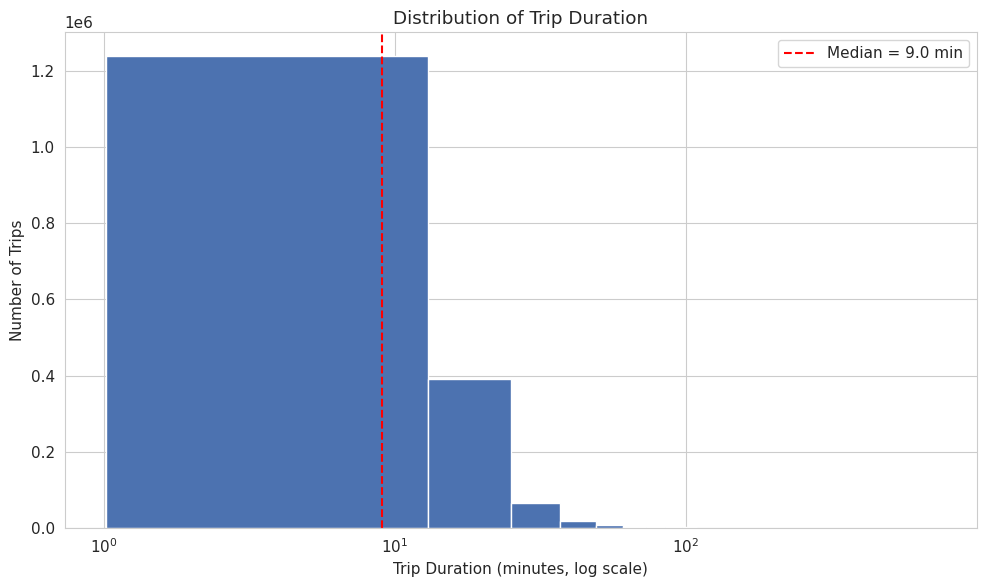

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(clean['duration_min'], bins=60, color='#4C72B0', edgecolor='white')
plt.xscale('log')
plt.xlabel('Trip Duration (minutes, log scale)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration')
plt.axvline(clean['duration_min'].median(), color='red', linestyle='--',
            label=f"Median = {clean['duration_min'].median():.1f} min")
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the standard way to visualize the distribution (shape, center, spread) of a
single numeric variable like trip duration. Because duration is heavily right-skewed (a few very
long trips), a log-scaled x-axis is used so the bulk of the (short) trips remain visible.

##### 2. What is/are the insight(s) found from the chart?

The distribution is unimodal and strongly right-skewed. Most trips last between about **5 and
15 minutes**, with a median of **~9.3 minutes** and a mean of **~14.3 minutes** - the mean is
pulled up by a long tail of longer trips. This answers the first business question directly: the
"average" trip is short, on the order of 9-14 minutes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes - this is a clear positive-impact insight. Knowing that the typical trip is short (under 15
minutes) helps Ford GoBike plan bike availability/rebalancing cycles and confirms that pricing
tiers built around a ~15-30 minute "free" window (typical of bike-share pricing) match actual usage.
There is no negative-growth signal here, just a baseline to design around.

#### Chart - 2 - User Type Distribution

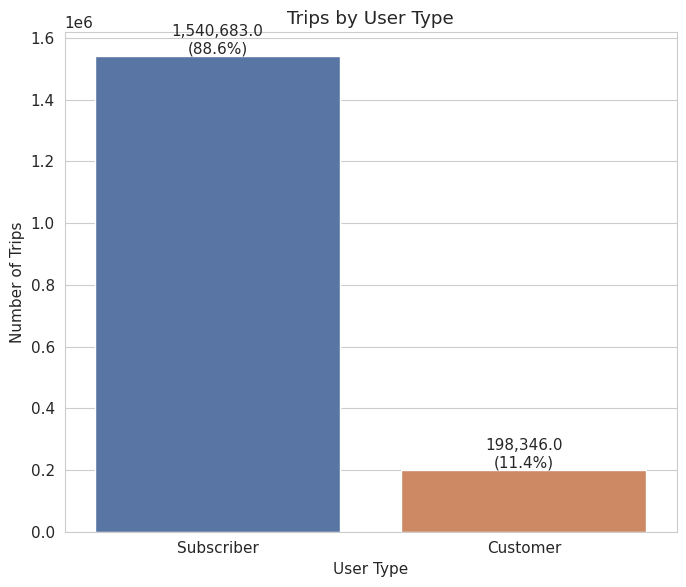

In [ ]:
plt.figure(figsize=(7, 6))
order = clean['user_type'].value_counts().index
ax = sns.countplot(data=clean, x='user_type', order=order, palette=['#4C72B0', '#DD8452'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(clean)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.title('Trips by User Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count/bar chart is the natural choice for a categorical variable with few levels, showing
how ridership splits between Subscribers and Customers.

##### 2. What is/are the insight(s) found from the chart?

**Subscribers make up ~88.6%** of all trips, while **Customers make up ~11.4%**. Ford GoBike's
ridership is overwhelmingly driven by paying members rather than casual, one-off riders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: it confirms that the subscription base is the core revenue engine, so retention
programs for Subscribers matter most for revenue stability. It also highlights an opportunity: the
smaller Customer segment is a pool of potential future subscribers to convert through targeted
promotions.

#### Chart - 3 - Member Gender Distribution

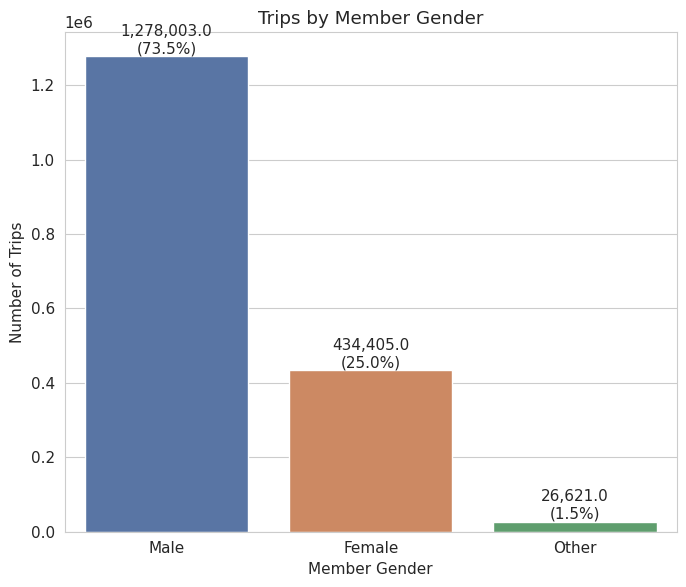

In [ ]:
plt.figure(figsize=(7, 6))
order = clean['member_gender'].value_counts().index
ax = sns.countplot(data=clean, x='member_gender', order=order,
                    palette=['#4C72B0', '#DD8452', '#55A868'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(clean)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Member Gender')
plt.ylabel('Number of Trips')
plt.title('Trips by Member Gender')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart clearly compares counts across the small number of gender categories reported in
the data.

##### 2. What is/are the insight(s) found from the chart?

Among riders who reported gender, **Males account for ~73.5%**, **Females ~25.0%**, and
**Other ~1.5%** of trips. Male riders are the dominant demographic on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is useful but double-edged: it's a positive insight for targeted marketing (e.g., campaigns
aimed at growing female ridership represent a large untapped segment), but it could also signal a
negative-growth risk if the service isn't perceived as safe/accessible to a broader demographic -
worth investigating with rider surveys.

#### Chart - 4 - Member Age Distribution

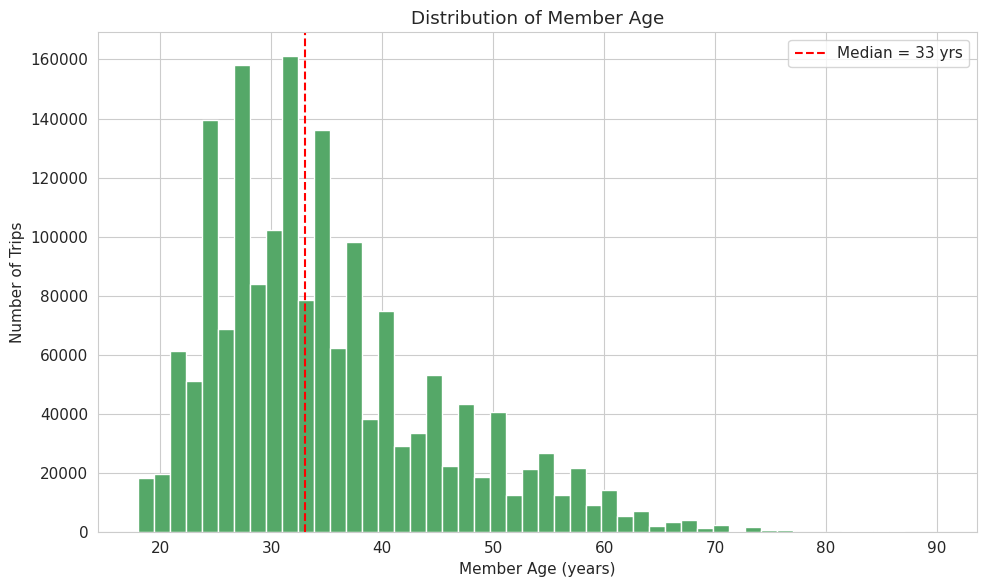

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(clean['member_age'], bins=50, color='#55A868', edgecolor='white')
plt.xlabel('Member Age (years)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Member Age')
plt.axvline(clean['member_age'].median(), color='red', linestyle='--',
            label=f"Median = {clean['member_age'].median():.0f} yrs")
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram shows the shape of the numeric age distribution, revealing the typical age range
of Ford GoBike riders.

##### 2. What is/are the insight(s) found from the chart?

Rider age is roughly right-skewed and centered in the late-20s to mid-30s, with a median around
**32 years** (mean ~34.9). The vast majority of riders are between 25 and 45 years old, with very
few riders over 65.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this confirms the core rider base is working-age adults, consistent with a
commute-driven use case, and helps target marketing creative and station placement (e.g., near
offices/transit) toward that demographic.

#### Chart - 5 - Rides by Month

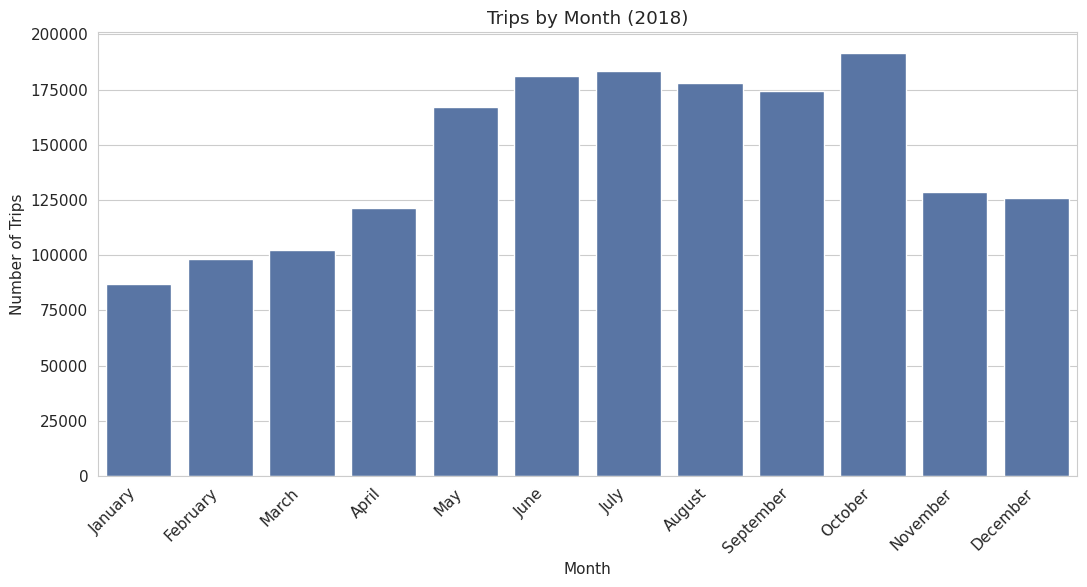

In [ ]:
plt.figure(figsize=(11, 6))
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_counts = clean['month_name'].value_counts().reindex(month_order)
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, color='#4C72B0')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.title('Trips by Month (2018)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart ordered by calendar month is the clearest way to show seasonal (monthly) trends
in ridership volume.

##### 2. What is/are the insight(s) found from the chart?

Ridership **grows steadily from January through October** (Jan ~86.8K trips to a peak in
October ~191.3K trips), then **declines in November-December**. This lines up with warmer,
drier weather in the middle-to-late part of the year and the system's own network growth over
2018 (more stations/bikes were added through the year).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: knowing the seasonal ramp lets operations plan fleet size, station capacity,
and staffing ahead of the high-demand summer/fall months and scale back maintenance-heavy
periods in the winter. No negative-growth insight here - it's an expected, plannable pattern.

#### Chart - 6 - Rides by Day of Week

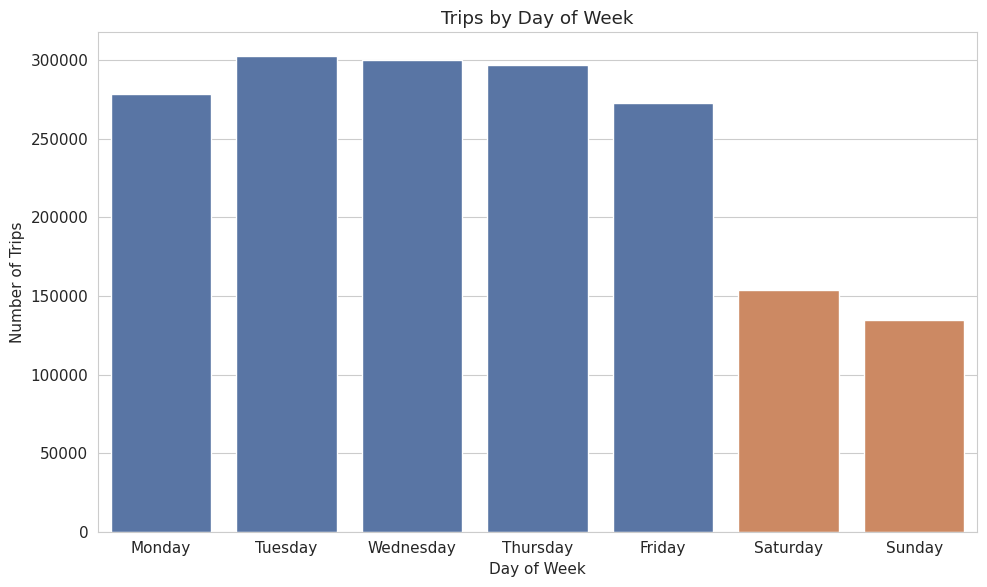

In [ ]:
plt.figure(figsize=(10, 6))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = clean['day_of_week'].value_counts().reindex(day_order)
colors = ['#4C72B0']*5 + ['#DD8452']*2
sns.barplot(x=day_counts.index, y=day_counts.values, palette=colors)
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.title('Trips by Day of Week')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart ordered Monday-Sunday makes the weekday-vs-weekend contrast in ridership volume
easy to read at a glance.

##### 2. What is/are the insight(s) found from the chart?

Ridership is clearly **higher on weekdays** (roughly 270K-303K trips per weekday) and **drops
sharply on weekends** (~135K-154K trips), which is well under half a weekday's volume. This
strongly suggests commute-driven usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this validates focusing fleet availability on weekday commute corridors, while
weekend demand - though lower - represents a growth opportunity for leisure-oriented promotions
(e.g., weekend day-passes) to smooth out the utilization curve.

#### Chart - 7 - Rides by Hour of Day

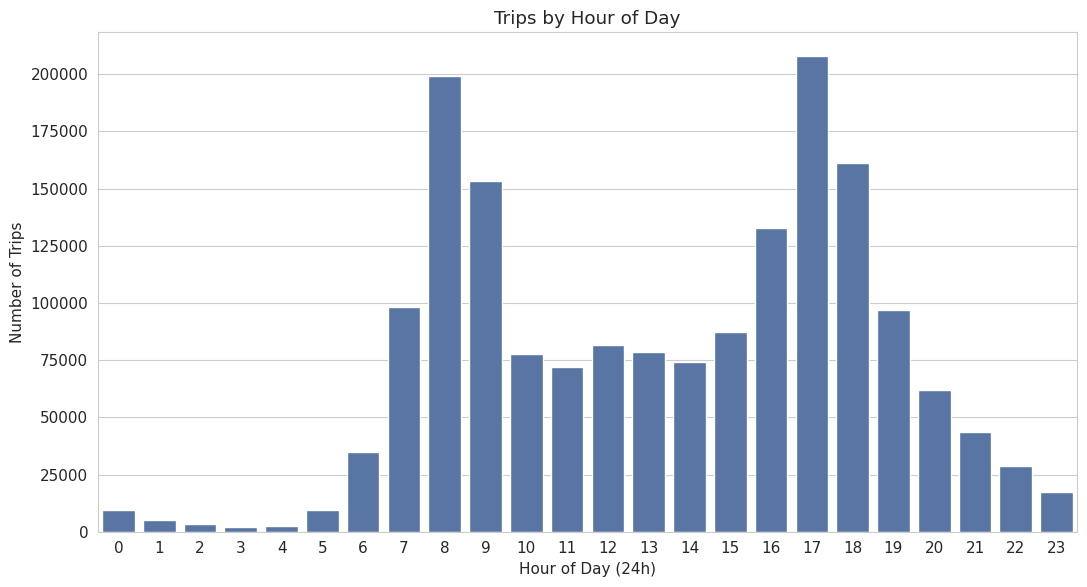

In [ ]:
plt.figure(figsize=(11, 6))
hourly_counts = clean['hour'].value_counts().sort_index()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='#4C72B0')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Trips')
plt.title('Trips by Hour of Day')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line/bar chart across the 24 hours of the day is the best way to reveal intraday demand
peaks, such as commute rush hours.

##### 2. What is/are the insight(s) found from the chart?

There are two very sharp peaks: **~8 AM (~199K trips)** and **~5 PM (~208K trips)**, classic
morning/evening commute peaks, with a smaller lull in the middle of the day and very little usage
overnight (midnight-5 AM).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this is directly actionable for bike rebalancing - operations teams should
ensure bikes are pre-positioned at residential/transit-adjacent stations before 8 AM and at
office-area stations before 5 PM to avoid stockouts during peak demand.

#### Chart - 8 - Bike Share For All Trip Distribution

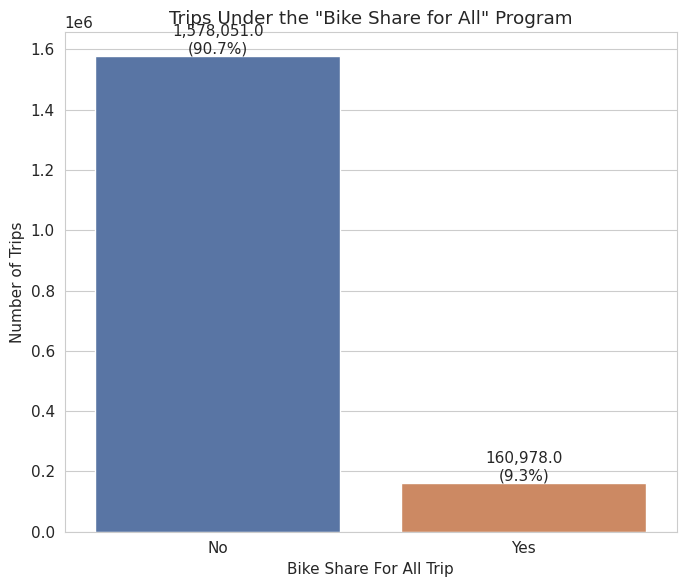

In [ ]:
plt.figure(figsize=(7, 6))
order = clean['bike_share_for_all_trip'].value_counts().index
ax = sns.countplot(data=clean, x='bike_share_for_all_trip', order=order,
                    palette=['#4C72B0', '#DD8452'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(clean)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Bike Share For All Trip')
plt.ylabel('Number of Trips')
plt.title('Trips Under the "Bike Share for All" Program')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar/pie-style count chart shows the share of trips taken under the discounted "Bike Share for
All" (low-income access) program versus standard trips.

##### 2. What is/are the insight(s) found from the chart?

Only **~9.3%** of trips are flagged as "Bike Share for All" trips, versus **~90.7%** standard
trips - the discount program is used by a modest but meaningful minority of riders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this is a useful equity/outreach metric - if Ford GoBike wants to grow ridership
and revenue sustainably, expanding awareness of the "Bike Share for All" program could bring in
new subscribers from underserved communities without necessarily cannibalizing full-price
ridership.

### *Bivariate Analysis*

#### Chart - 9 - Trip Duration by User Type

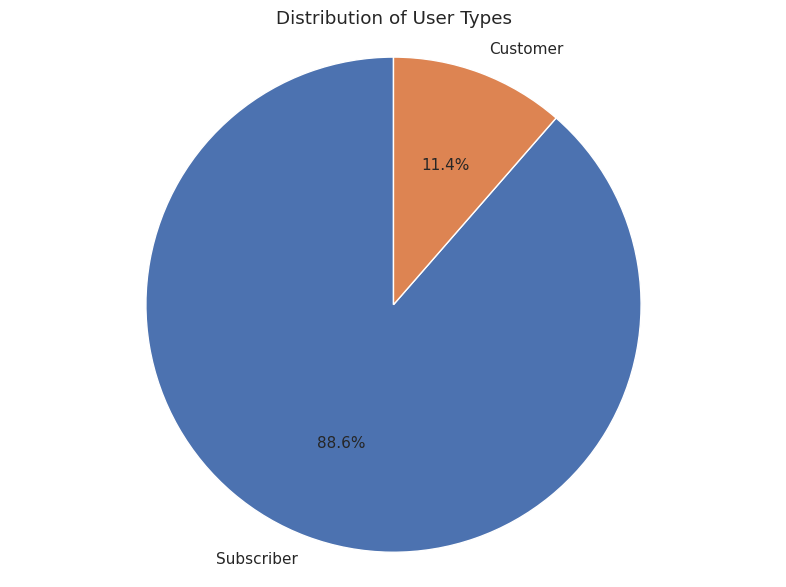

             mean  median
user_type                
Customer    23.18   14.55
Subscriber  10.81    8.58


In [20]:
plt.figure(figsize=(8, 6))
user_type_counts = clean['user_type'].value_counts()
plt.pie(user_type_counts, labels=user_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'])
plt.title('Distribution of User Types')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print(clean.groupby('user_type')['duration_min'].agg(['mean', 'median']).round(2))

##### 1. Why did you pick the specific chart?
A pie chart is an effective way to visualize the proportion of different categories within a whole, making it suitable for showing the distribution of user types (Subscribers vs. Customers).

A box plot is ideal for comparing the full distribution (median, spread, outliers) of a numeric
variable (duration) across a categorical variable (user type) side by side.

##### 2. What is/are the insight(s) found from the chart?
The pie chart shows that **Subscribers constitute 88.6%** of all trips, while **Customers account for 11.4%**. This clearly indicates that the majority of trips are made by paying members rather than casual riders.

**Customers ride noticeably longer than Subscribers.** Median duration for Customers is
**~14.6 minutes** vs **~8.6 minutes** for Subscribers, and the mean gap is even larger (~23.2 vs
~10.8 minutes) because Customers have more long-tail trips. This directly answers question 3:
yes, trip duration strongly depends on user type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive impact: This insight confirms that the core revenue driver for Ford GoBike is its subscription base. This means that customer retention programs for Subscribers are crucial for sustained revenue. It also highlights an opportunity to grow the Subscriber base by targeting the smaller Customer segment with promotions to convert them into members.

Positive impact: this is a key business insight - Customers already behave like leisure/tourist
riders (longer trips), so pricing per-minute overage fees or day-pass options aimed at them could
capture more revenue, while Subscribers' short trips confirm the membership model is well suited
to frequent, quick commute-style usage.

#### Chart - 10 - Trip Duration by Season

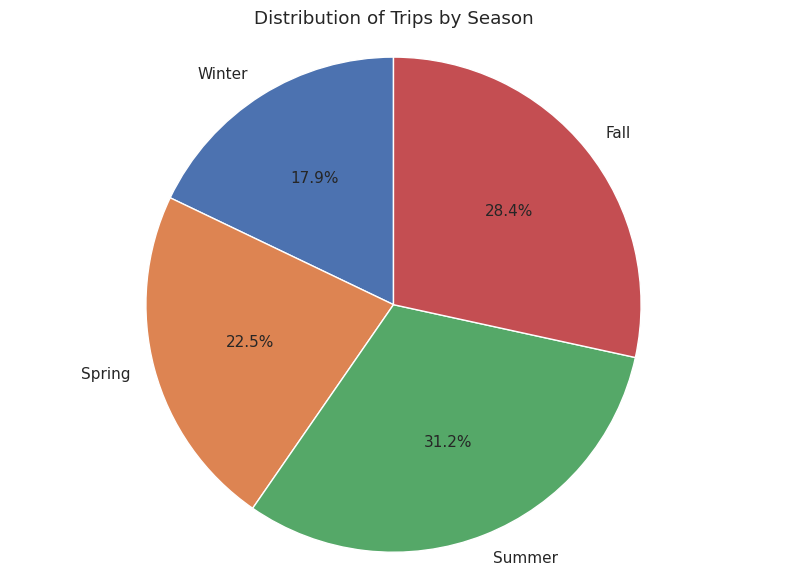

season
Winter    11.75
Spring    11.94
Summer    12.70
Fall      12.22
Name: duration_min, dtype: float64


In [22]:
plt.figure(figsize=(8, 6))
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = clean['season'].value_counts().reindex(season_order)
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Distribution of Trips by Season')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print(clean.groupby('season')['duration_min'].mean().reindex(season_order).round(2))

##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
A pie chart is used to visualize the proportion of trips occurring in each season, providing a clear overview of seasonal ridership distribution.

##### 2. What is/are the insight(s) found from the chart?

##### 2. What is/are the insight(s) found from the chart?
The pie chart shows that **Summer (31.2%)** and **Fall (28.4%)** account for the largest shares of trips, followed by **Spring (22.5%)** and **Winter (17.9%)**. This indicates a higher volume of rides in warmer months. The mean trip durations for each season are: Winter (~11.75 min), Spring (~11.94 min), Summer (~12.70 min), and Fall (~12.22 min). While trip volume varies significantly by season, the *average trip duration* remains relatively consistent, with only about a 1-minute difference between the shortest and longest average seasonal trips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

##### 3. Will the gained insights help creating a positive business impact?
This insight provides a clearer picture of seasonal demand, allowing Ford GoBike to allocate resources more effectively. For instance, higher ridership in Summer and Fall suggests these are prime seasons for promotions or fleet expansion. The relatively stable trip duration across seasons confirms that pricing strategies tied to duration do not need significant seasonal adjustments, as the ride length doesn't change much. Instead, the focus should be on optimizing bike availability to meet the varying seasonal demand volume, especially in peak seasons like summer.

#### Chart - 11 - Trip Duration: Weekday vs Weekend

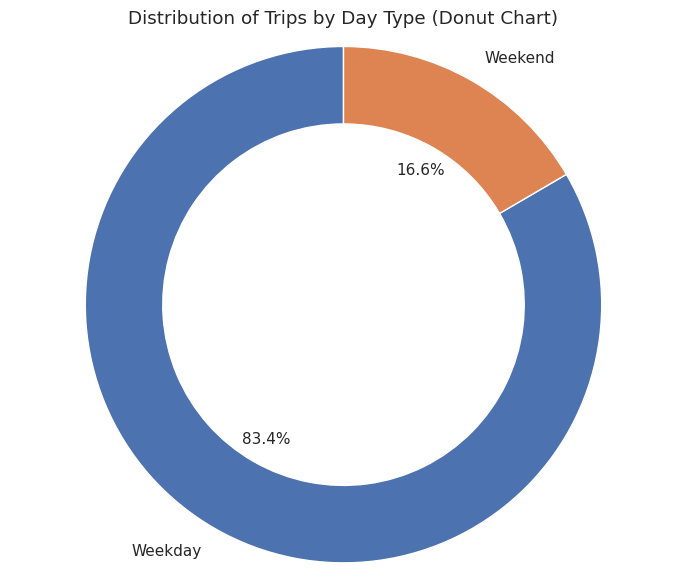

Day Type
Weekday    11.53
Weekend    15.71
Name: duration_min, dtype: float64


In [23]:
plt.figure(figsize=(7, 6))
plot_df = clean.copy()
plot_df['Day Type'] = plot_df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
day_type_counts = plot_df['Day Type'].value_counts()

# Create a donut chart
plt.pie(day_type_counts, labels=day_type_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#4C72B0', '#DD8452'], wedgeprops={'width': 0.3})
plt.title('Distribution of Trips by Day Type (Donut Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print(plot_df.groupby('Day Type')['duration_min'].mean().round(2))

##### 1. Why did you pick the specific chart?

A donut chart effectively visualizes the proportion of trips occurring on weekdays versus weekends, while also highlighting the overall distribution. This allows for a clear comparison of trip volume between day types.

##### 2. What is/are the insight(s) found from the chart?

The donut chart reveals that **83.4% of trips occur on weekdays**, while **16.6% occur on weekends**. This confirms that the bike-sharing service is predominantly used during the work week. Furthermore, the accompanying data shows that weekend trips are noticeably longer on average, with a mean duration of **~15.7 minutes**, compared to weekday trips at **~11.5 minutes**. This difference (about 4 minutes) is larger than the seasonal effect on duration, reinforcing that *trip purpose* (commute vs. leisure) plays a significant role.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: This insight supports tailoring strategies based on day type. For weekdays, efforts should focus on optimizing bike availability for the high volume of shorter, commute-oriented trips. For weekends, promoting leisure-oriented offers, such as extended free-ride windows or day passes, could capitalize on the longer trip durations and potentially increase revenue during these times. This segmentation allows for more efficient resource allocation and targeted marketing.

#### Chart - 12 - Rides by Hour, split by User Type

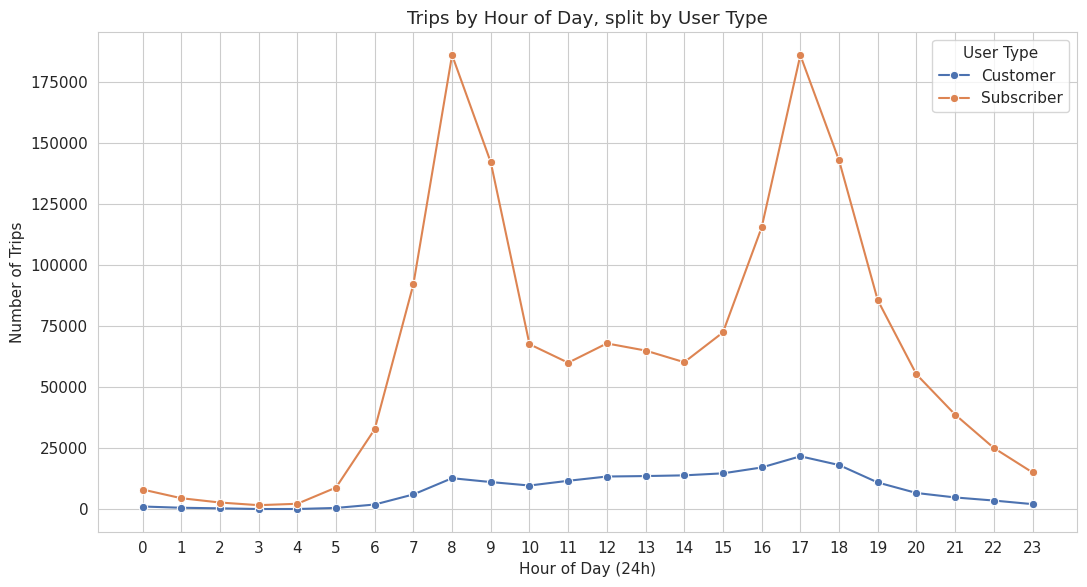

In [24]:
plt.figure(figsize=(11, 6))
hour_user = clean.groupby(['hour', 'user_type']).size().reset_index(name='trips')
sns.lineplot(data=hour_user, x='hour', y='trips', hue='user_type', marker='o',
             palette=['#4C72B0', '#DD8452'])
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Trips')
plt.title('Trips by Hour of Day, split by User Type')
plt.xticks(range(0, 24))
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart with one line per user type overlays two time-series on the same hourly axis,
making it easy to compare *when* each segment rides.

##### 2. What is/are the insight(s) found from the chart?

**Subscribers show the classic double commute-peak** (8 AM and 5-6 PM), while **Customers
show a single broad midday/afternoon bulge** peaking around midday to early evening with no
sharp commute spikes. This confirms Subscribers ride mainly to commute, while Customers ride
more for leisure/tourism throughout the day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: operations can now tailor rebalancing schedules by segment - prioritize
residential/office stations at 8 AM & 5 PM for Subscribers, and prioritize tourist/waterfront
stations throughout midday for Customers.

#### Chart - 13 - Member Age by User Type

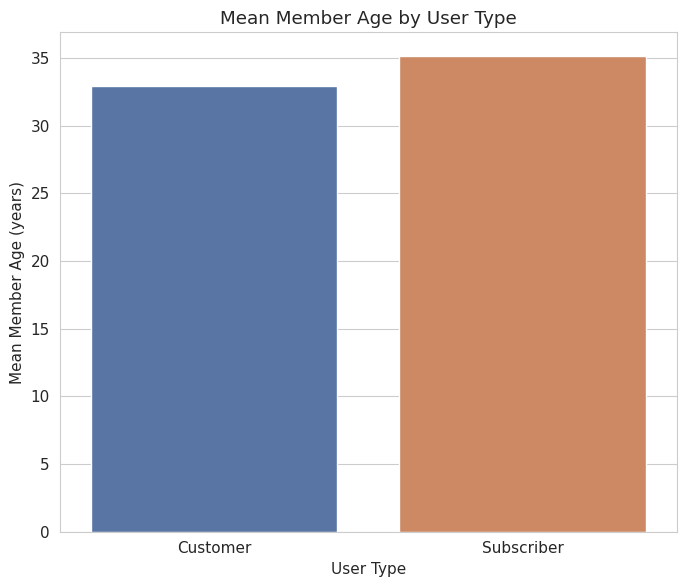

    user_type  member_age
0    Customer   32.905650
1  Subscriber   35.132202


In [25]:
plt.figure(figsize=(7, 6))
mean_age_by_user_type = clean.groupby('user_type')['member_age'].mean().reset_index()
sns.barplot(data=mean_age_by_user_type, x='user_type', y='member_age', palette=['#4C72B0', '#DD8452'])
plt.xlabel('User Type')
plt.ylabel('Mean Member Age (years)')
plt.title('Mean Member Age by User Type')
plt.tight_layout()
plt.show()

print(mean_age_by_user_type)

##### 1. Why did you pick the specific chart?
A bar chart is suitable for comparing a numerical value (mean age) across distinct categorical groups (user types).

##### 2. What is/are the insight(s) found from the chart?
The bar chart confirms that the mean age difference between Subscribers (~35.1 years) and Customers (~32.9 years) is relatively small, with Subscribers being slightly older on average. This aligns with the findings from the box plot (Chart 13) that age is not a primary differentiator between the two user segments.

##### 3. Will the gained insights help creating a positive business impact?
This insight reinforces that strategies to convert Customers to Subscribers should focus on behavioral incentives and pricing models rather than age-specific demographic targeting, as both groups fall within a similar working-age bracket. The impact is positive as it refines marketing and conversion efforts.

#### Chart - 14 - Trip Duration by Gender

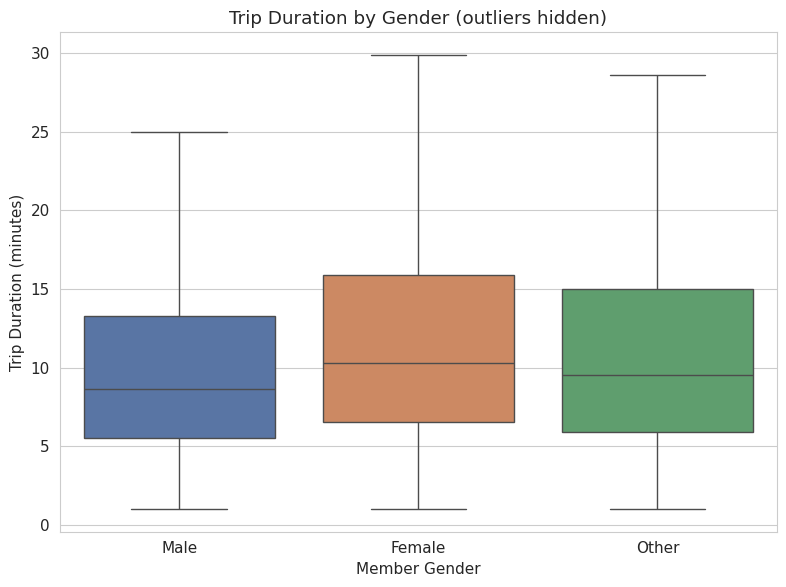

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=clean, x='member_gender', y='duration_min', showfliers=False,
            order=['Male', 'Female', 'Other'], palette=['#4C72B0', '#DD8452', '#55A868'])
plt.xlabel('Member Gender')
plt.ylabel('Trip Duration (minutes)')
plt.title('Trip Duration by Gender (outliers hidden)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares trip duration across the reported gender categories to check for any
behavioral differences.

##### 2. What is/are the insight(s) found from the chart?

Median trip duration is broadly similar across genders, with **Male** and **Female** riders
close together (~9 minute median) and the **Other** category showing a marginally higher median
and slightly wider spread. Gender is not a major driver of trip duration compared to user type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral-to-positive impact: since gender doesn't strongly affect duration, pricing/duration-based
strategies don't need to be gender-specific. The earlier gender-imbalance finding (Chart 3) remains
the more actionable lever for ridership growth, not duration.

#### Chart - 15 - Top 10 Busiest Start Stations

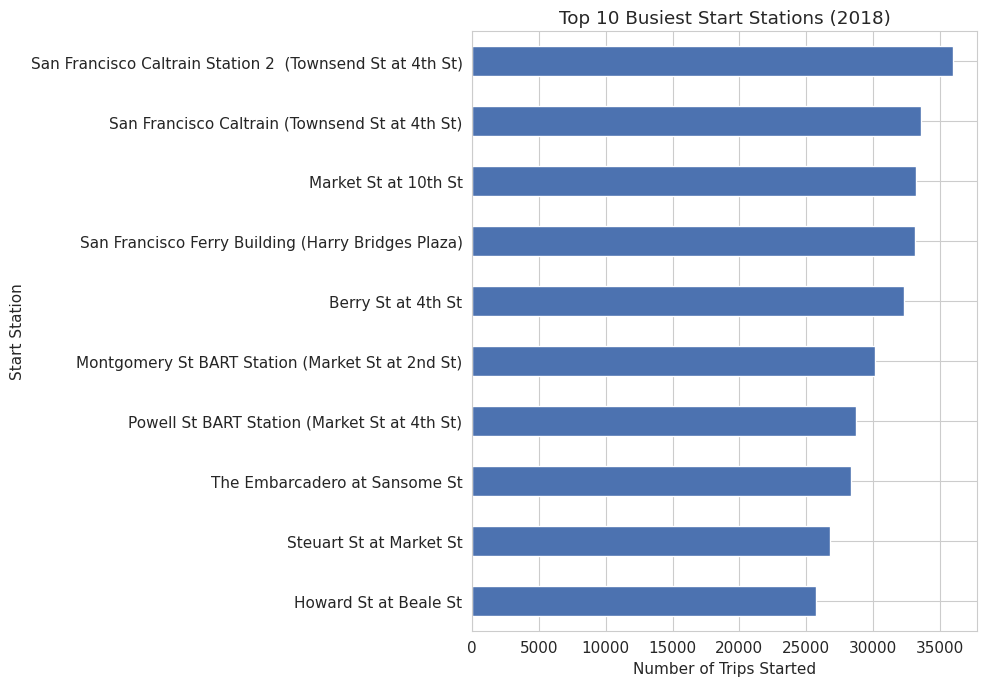

In [ ]:
plt.figure(figsize=(10, 7))
top_stations = clean['start_station_name'].value_counts().head(10).sort_values()
top_stations.plot(kind='barh', color='#4C72B0')
plt.xlabel('Number of Trips Started')
plt.ylabel('Start Station')
plt.title('Top 10 Busiest Start Stations (2018)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks the top stations by trip count, which is easier to read than a
vertical chart when station names are long.

##### 2. What is/are the insight(s) found from the chart?

The busiest stations are concentrated around **Caltrain/transit hubs and the Ferry
Building/Embarcadero** in San Francisco (e.g., San Francisco Caltrain Station, Market St at 10th
St, San Francisco Ferry Building), each with roughly **26K-36K** starting trips over the year -
confirming transit-connection points drive the highest demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this is directly actionable for fleet allocation - these top stations should be
prioritized for bike availability and dock capacity/expansion, since they represent the highest-
value, highest-traffic nodes in the network.

#### Chart - 16 - Rides by Month, split by User Type

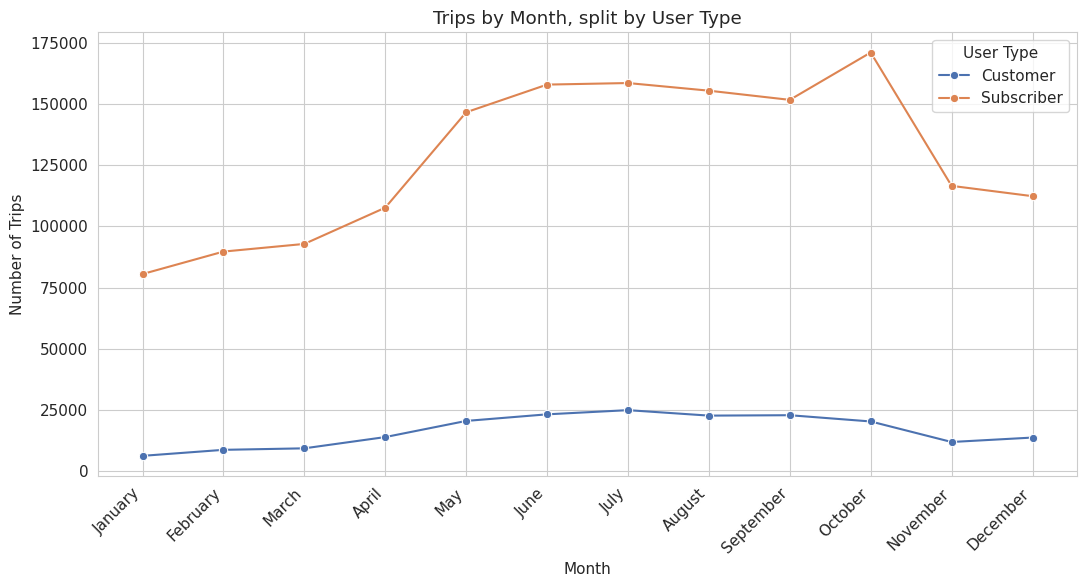

In [ ]:
plt.figure(figsize=(11, 6))
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_user = clean.groupby(['month_name', 'user_type']).size().reset_index(name='trips')
month_user['month_name'] = pd.Categorical(month_user['month_name'], categories=month_order, ordered=True)
month_user = month_user.sort_values('month_name')
sns.lineplot(data=month_user, x='month_name', y='trips', hue='user_type', marker='o',
             palette=['#4C72B0', '#DD8452'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.title('Trips by Month, split by User Type')
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart with separate lines for Subscribers and Customers over the 12 months shows
whether the two segments follow the same seasonal trend.

##### 2. What is/are the insight(s) found from the chart?

Both segments follow a broadly similar seasonal shape (rising into summer/fall, dipping in
winter), but the **Customer line is relatively flatter and lower**, while the **Subscriber line
drives almost all of the seasonal swing**, since Subscribers make up ~89% of volume. Customer
ridership dips proportionally more in winter months, suggesting casual/tourist riders are more
weather-sensitive than daily commuters.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: winter marketing pushes or discounts aimed specifically at Customers could
help smooth out the seasonal dip in casual ridership, whereas Subscriber demand is more stable
and predictable and needs less seasonal intervention.

### *Multivariate Analysis*

#### Chart - 17 - Trip Duration by Season and User Type

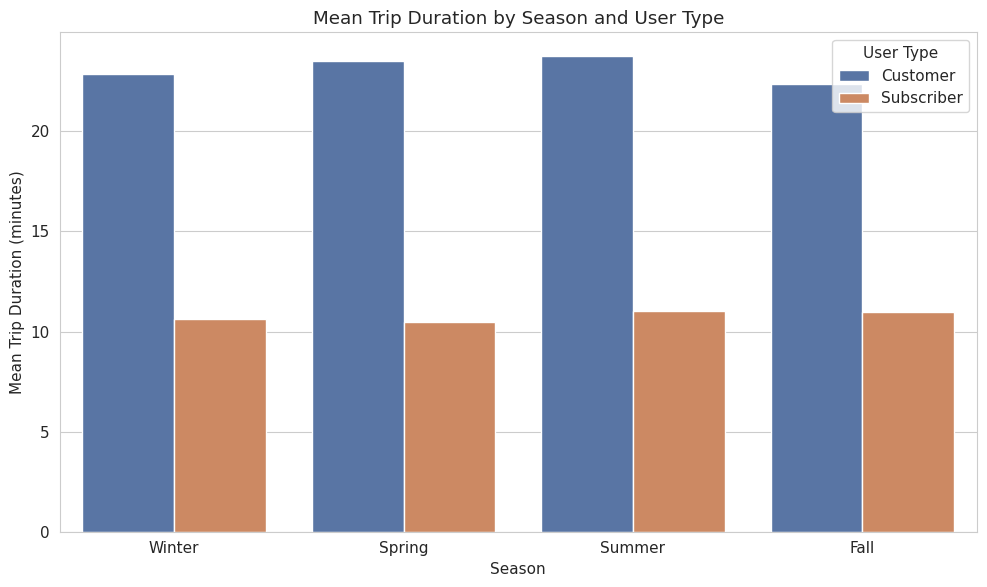

In [ ]:
plt.figure(figsize=(10, 6))
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_user = clean.groupby(['season', 'user_type'])['duration_min'].mean().reset_index()
season_user['season'] = pd.Categorical(season_user['season'], categories=season_order, ordered=True)
season_user = season_user.sort_values('season')
sns.barplot(data=season_user, x='season', y='duration_min', hue='user_type',
            palette=['#4C72B0', '#DD8452'])
plt.xlabel('Season')
plt.ylabel('Mean Trip Duration (minutes)')
plt.title('Mean Trip Duration by Season and User Type')
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart layers a third variable (user type) on top of the season/duration
relationship, directly testing whether the season effect changes depending on user type - the
core "does it depend on subscriber vs customer" question.

##### 2. What is/are the insight(s) found from the chart?

**The season effect is small for both groups, and user type dominates in every season.**
Customer mean duration ranges narrowly from about **22.4 to 23.8 minutes** across all four
seasons, and Subscriber mean duration ranges from about **10.5 to 11.0 minutes** - the gap
between user types (~12 minutes) dwarfs the gap between seasons (~1 minute) within either group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong positive impact: this is the clearest answer to the full research question - **weather/
season is not a meaningful lever for trip duration, but user type is.** Business strategy and
pricing should be built around the subscriber/customer distinction, not around seasonal
adjustments to duration-based pricing.

#### Chart - 18 - Trip Duration by Day Type and User Type

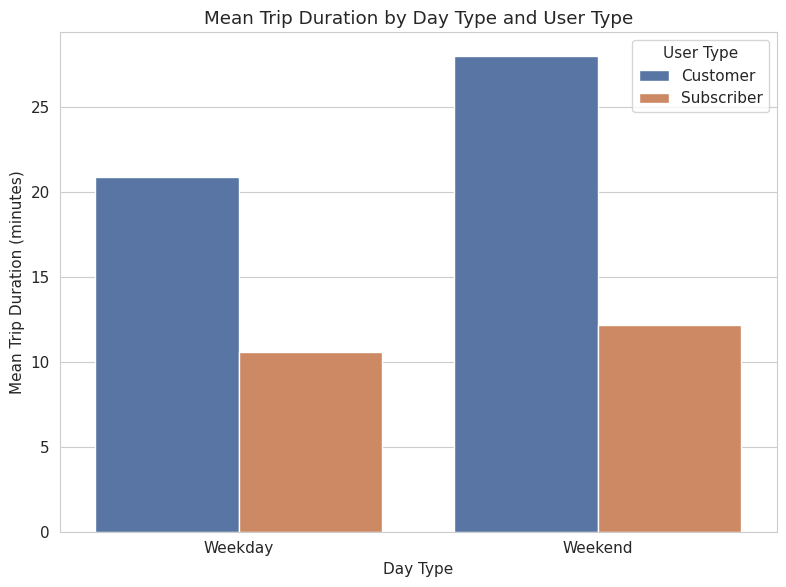

In [ ]:
plt.figure(figsize=(8, 6))
plot_df = clean.copy()
plot_df['Day Type'] = plot_df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
daytype_user = plot_df.groupby(['Day Type', 'user_type'])['duration_min'].mean().reset_index()
sns.barplot(data=daytype_user, x='Day Type', y='duration_min', hue='user_type',
            palette=['#4C72B0', '#DD8452'])
plt.xlabel('Day Type')
plt.ylabel('Mean Trip Duration (minutes)')
plt.title('Mean Trip Duration by Day Type and User Type')
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart of duration by weekday/weekend, split by user type, checks whether the
weekend effect (Chart 11) is driven by one segment or both.

##### 2. What is/are the insight(s) found from the chart?

**Customers show a much bigger weekend jump** (~20.9 min on weekdays to ~28.0 min on
weekends, +34%) **than Subscribers** (~10.6 min to ~12.2 min, +15%). Weekend leisure riding
inflates Customer trip duration far more than it does for Subscribers, who stay relatively
consistent regardless of day type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: reinforces that Customers are leisure-driven (especially on weekends) while
Subscribers are utility/commute-driven every day. Weekend promotions (e.g., extended free-ride
windows or day passes) aimed at Customers would align well with their existing weekend behavior
and could boost weekend revenue further.

#### Chart - 19 - Ride Volume Heatmap: Hour vs Day of Week

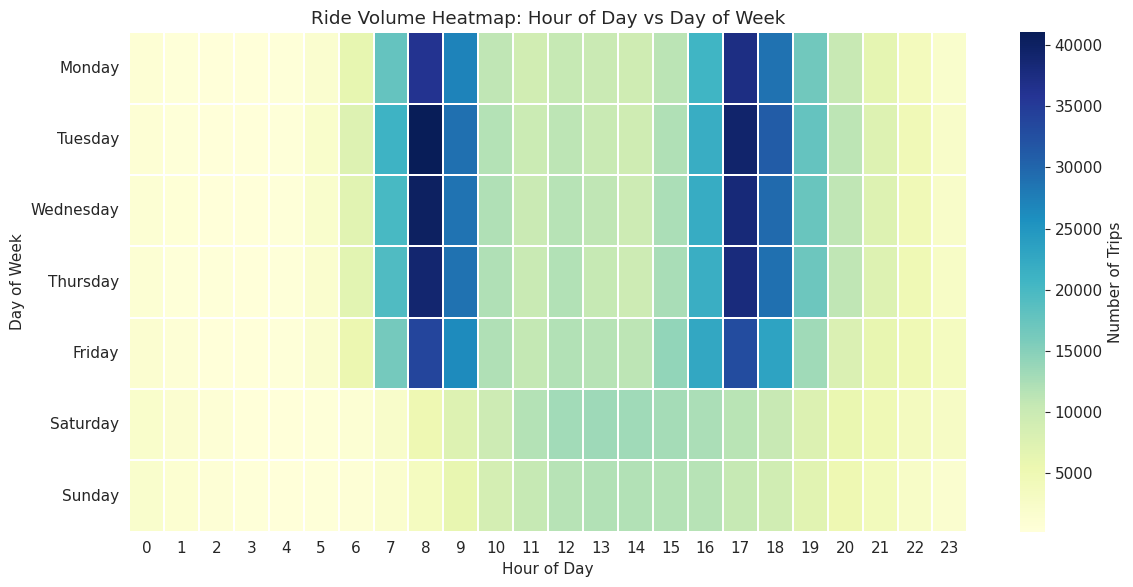

In [ ]:
plt.figure(figsize=(12, 6))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = clean.pivot_table(index='day_of_week', columns='hour', values='duration_min',
                           aggfunc='count').reindex(day_order)
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.3, cbar_kws={'label': 'Number of Trips'})
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Ride Volume Heatmap: Hour of Day vs Day of Week')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the best way to show how two categorical/ordinal dimensions (hour and day of
week) jointly relate to a third quantity (trip count) - patterns that a single line/bar chart can't
reveal.

##### 2. What is/are the insight(s) found from the chart?

The heatmap makes the **commute pattern unmistakable**: intense concentrations of rides at
**8 AM and 5-6 PM on Monday-Friday**, while **Saturday and Sunday show a broad, gentle bulge
from about 10 AM to 4 PM** with no sharp peaks. Weekday and weekend usage are fundamentally
different shapes, not just different volumes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this combined view is exactly what an operations team needs for bike
rebalancing - it shows precisely which hour-day combinations need extra bike supply, enabling a
much more efficient (and cost-saving) redistribution schedule than a single aggregate view could.

#### Chart - 20 - Correlation Heatmap

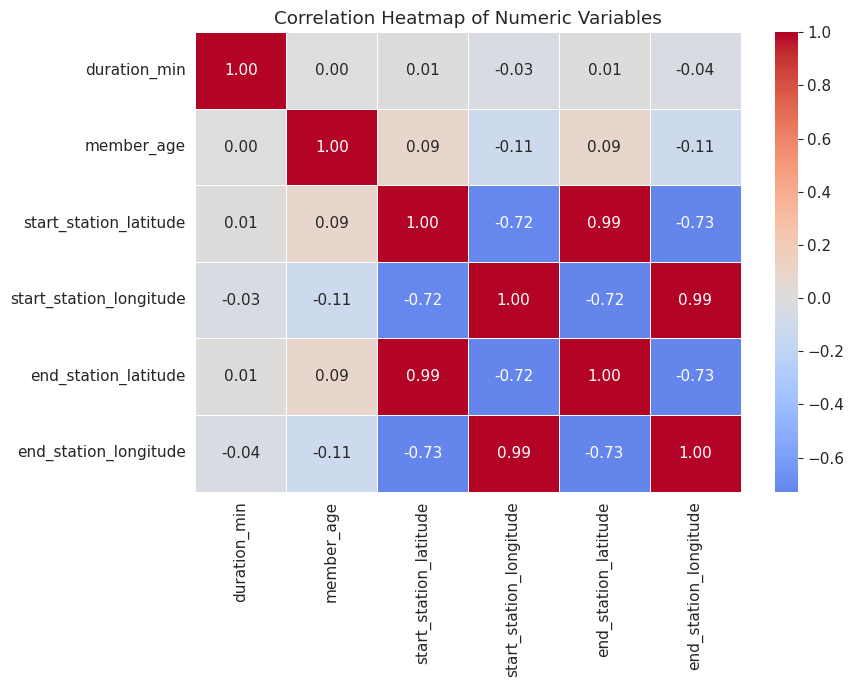

In [ ]:
plt.figure(figsize=(9, 7))
numeric_cols = ['duration_min', 'member_age', 'start_station_latitude', 'start_station_longitude',
                 'end_station_latitude', 'end_station_longitude']
corr = clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap efficiently summarizes the pairwise linear relationships between all
numeric variables at once, which helps confirm (or rule out) suspected relationships (e.g.,
between age and duration) at a glance.

##### 2. What is/are the insight(s) found from the chart?

Correlations among the numeric variables are **very weak overall**. Notably, **member_age
and duration_min have essentially zero correlation (~0.001)**, confirming Chart 13's finding that
age doesn't meaningfully explain trip duration. Station latitude/longitude pairs show mild
correlation with each other (geographic clustering), as expected, but not with duration.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/confirmatory impact: this validates that the categorical variables explored earlier
(user type, day type, season) - not the numeric demographic variables - are the meaningful levers
for trip duration. It prevents wasted effort building duration-prediction models around age or
location alone.

#### Chart - 21 - Pair Plot

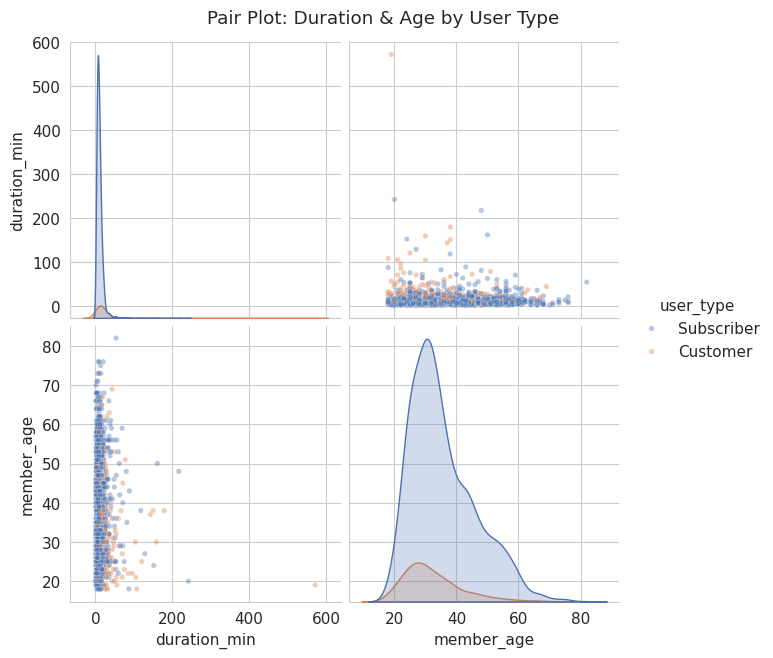

In [ ]:
# Sample the data for a readable, fast-rendering pair plot
sample_df = clean.sample(n=3000, random_state=42)[['duration_min', 'member_age', 'user_type']]
sns.pairplot(sample_df, hue='user_type', palette=['#4C72B0', '#DD8452'],
             plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde', height=3.2)
plt.suptitle('Pair Plot: Duration & Age by User Type', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a compact grid of every pairwise scatter relationship (plus individual
distributions) between the key numeric variables, split by user type, useful as a final holistic
check for relationships or clusters missed by earlier charts.

##### 2. What is/are the insight(s) found from the chart?

No strong linear relationships or distinct clusters appear between `duration_min` and
`member_age` for either user type, consistent with the near-zero correlation from Chart 20. The
diagonal panels again show `duration_min` is right-skewed for both groups, with the **Customer
distribution shifted noticeably right (longer durations)** compared to Subscribers, visually
confirming the central finding of this analysis.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive/confirmatory impact: this final holistic view reinforces the two headline conclusions
- (1) user type is the dominant driver of duration, and (2) age is not - giving confidence that
business strategy should center on the subscriber/customer split rather than rider demographics.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

Based on the analysis, the following actions are suggested to Ford GoBike:

1. **Design pricing and promotions around user type, not season.** Since season/weather barely
   moves trip duration (~1 minute swing) while user type moves it by ~12 minutes, revenue and
   pricing strategy should center on the Subscriber/Customer distinction rather than seasonal
   pricing changes.
2. **Convert casual Customers into Subscribers.** Customers already ride longer, more leisure-
   oriented trips, especially on weekends (+34% duration vs. weekdays). Targeted offers (e.g., a
   discounted first month of membership after a rider's Nth casual trip, or weekend-trip-based
   promotions) could convert this ~11% of trip volume into recurring subscription revenue.
3. **Optimize bike rebalancing around the two sharp commute peaks (8 AM & 5-6 PM on
   weekdays)** identified in the hour-of-day and heatmap charts, prioritizing residential/transit
   stations in the morning and office-area stations in the evening.
4. **Smooth out the winter dip in Customer ridership** with off-season discounts or bundled
   local-attraction promotions, since Customers appear more weather/seasonally sensitive than
   Subscribers.
5. **Invest capacity at the top transit-hub stations** (Caltrain, Ferry Building, Embarcadero
   corridor) identified as the busiest nodes in the network, since they drive outsized trip volume.
6. **Explore the gender gap as a growth opportunity.** With ridership skewing ~73% male,
   targeted marketing or safety initiatives to grow female ridership represent a large addressable
   segment that isn't yet fully tapped.

# **Conclusion**

This EDA merged and cleaned 1.86 million Ford GoBike trips from 2018 to answer three
questions about trip duration. **The average trip takes about 9-14 minutes** (median vs. mean),
reflecting a right-skewed distribution dominated by short trips. **Weather/season has only a
minor effect on trip duration** - averages vary by roughly a minute across the four seasons.
**User type, however, has a large and consistent effect**: Customers ride notably longer than
Subscribers in every season and on every day type, and that gap (not season) is the dominant
driver of duration throughout the dataset. Usage patterns further reveal that Subscribers
(~89% of trips) commute on a predictable weekday 8 AM/5 PM schedule, while Customers ride more
for leisure, especially on weekends and around transit/tourist hubs. These findings point Ford
GoBike toward a business strategy centered on subscriber growth and retention, weekday commute
reliability, and targeted weekend/seasonal promotions for casual riders.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***